When you extract frequent itemsets (words or sets of words that appear together often across your sentences), you reveal underlying structure:

Sentences that share many frequent itemsets are likely to be similar—for example, about the same topic or intent.

This means your sentences can be grouped (clustered) based on how much they “share” these itemsets.

# André

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from itertools import combinations

# Data Input (data inputed already cleaned from TF-IDF)

Input the data, split each sentence into words, and remove punctuation except for apostrophes.

In [3]:
data = pd.read_csv('../data/horoscope_cleaned_final.csv')

data.columns
#data = data.head(10000)

Index(['ID', 'sign', 'category', 'date', 'horoscope', 'horoscope_cleaned'], dtype='object')

In [4]:
#data.rename(columns={'horoscope': 'token'}, inplace=True)
data.rename(columns={'horoscope_cleaned': 'token'}, inplace=True)

In [5]:
import re

def clean_keep_apostrophe(text):
    # Only keep letters, digits, apostrophes, and whitespace
    return re.sub(r"[^\w\d'\s]", "", text)

# Apply to your DataFrame
data['token'] = data['token'].apply(clean_keep_apostrophe)
data['token'] = data['token'].str.split()
data["token"] = data["token"].apply(lambda x: [w.lower() for w in x])

In [6]:
data

,ID,sign,category,date,horoscope,token
0,1,aries,general,20200617,"There's a great day ahead of you, Aries. You'l...","[there's, great, ahead, you'll, blessed, abili..."
1,2,aries,general,20200618,People will understand and appreciate your des...,"[understand, appreciate, desire, stand, crowd,..."
2,3,aries,general,20200619,You are very interested in technological break...,"[interested, technological, breakthroughs, inn..."
3,4,aries,general,20200620,Stress from overwork could have you feeling we...,"[stress, overwork, feeling, weaker, usual, tem..."
4,5,aries,general,20200621,This is a good day to stand up for yourself an...,"[stand, known, aren't, pushover, use, powerful..."
...,...,...,...,...,...,...
17562,21589,pisces,wellness,20210612,The current planetary influence encourages you...,"[current, influence, encourages, question, per..."
17563,21590,pisces,wellness,20210613,Take a look at what matters most to you in the...,"[look, matters, most, world, somewhere, list, ..."
17564,21591,pisces,wellness,20210614,The balancing acts our bodies perform daily ta...,"[balancing, acts, our, bodies, perform, daily,..."
17565,21592,pisces,wellness,20210615,Today's planetary configuration could make you...,"[configuration, sense, loneliness, realize, im..."


In [16]:
data["original_token_size"] = data["token"].apply(len)
data["original_token_size"].describe()

count    17567.000000
mean        27.597256
std          7.764977
min         10.000000
25%         22.000000
50%         27.000000
75%         32.000000
max         85.000000
Name: original_token_size, dtype: float64

# Word Data (Counter)

This section holds the word frequency counts (word counter) computed from the cleaned text.

In [8]:
data["original_sentence"] = data["token"]
longer_data = data.explode('token').rename(columns={'token': 'word'})
longer_data['word'] = longer_data['word'].str.lower()

longer_data

,ID,sign,category,date,horoscope,word,original_token_size,original_sentence
0,1,aries,general,20200617,"There's a great day ahead of you, Aries. You'l...",there's,26,"[there's, great, ahead, you'll, blessed, abili..."
0,1,aries,general,20200617,"There's a great day ahead of you, Aries. You'l...",great,26,"[there's, great, ahead, you'll, blessed, abili..."
0,1,aries,general,20200617,"There's a great day ahead of you, Aries. You'l...",ahead,26,"[there's, great, ahead, you'll, blessed, abili..."
0,1,aries,general,20200617,"There's a great day ahead of you, Aries. You'l...",you'll,26,"[there's, great, ahead, you'll, blessed, abili..."
0,1,aries,general,20200617,"There's a great day ahead of you, Aries. You'l...",blessed,26,"[there's, great, ahead, you'll, blessed, abili..."
...,...,...,...,...,...,...,...,...
17566,21593,pisces,wellness,20210616,"In order to be an active thinker, it helps to ...",champion,37,"[order, active, thinker, helps, keep, active, ..."
17566,21593,pisces,wellness,20210616,"In order to be an active thinker, it helps to ...",silent,37,"[order, active, thinker, helps, keep, active, ..."
17566,21593,pisces,wellness,20210616,"In order to be an active thinker, it helps to ...",oppressed,37,"[order, active, thinker, helps, keep, active, ..."
17566,21593,pisces,wellness,20210616,"In order to be an active thinker, it helps to ...",only,37,"[order, active, thinker, helps, keep, active, ..."


In [9]:
word_counter = longer_data['word'].value_counts().reset_index()
word_counter.columns = ['word', 'count']
word_counter= word_counter.sort_values(by='count', ascending=False)

# Show the counts
word_counter.head(10)

,word,count
0,you're,2094
1,exercise,1938
2,right,1786
3,give,1759
4,current,1754
5,feeling,1735
6,even,1734
7,too,1701
8,any,1674
9,know,1667


953
1600


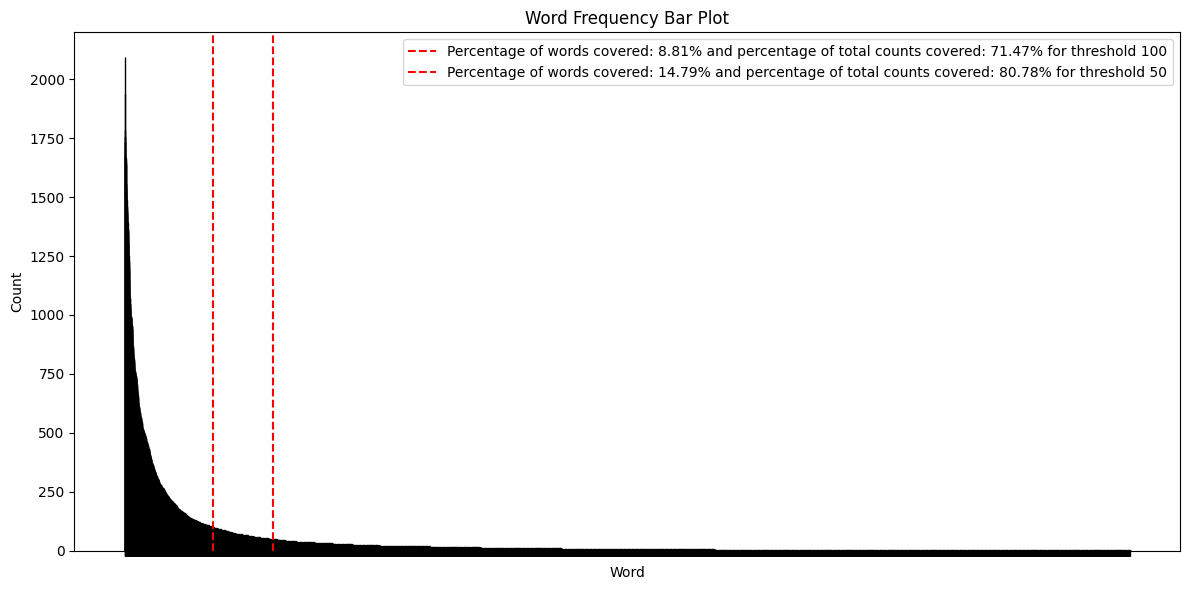

In [12]:
# Plot setup
fig, ax = plt.subplots(figsize=(12, 6))

word_counter_sorted = word_counter
thresholds = [100, 50]  # Example thresholds

# Bar plot: Words on x-axis, counts on y-axis
ax.bar(
    word_counter_sorted['word'],
    word_counter_sorted['count'],
    color='skyblue',
    edgecolor='black'
)

# Title and axis labels (use ax.set_*, not ax.*)
ax.set_title('Word Frequency Bar Plot')
ax.set_xlabel('Word')
ax.set_ylabel('Count')
ax.set_xticklabels([])

# Rotate x-tick labels for readability
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# Draw a vertical line at the 10th bar (adjust as needed)

positions = [
    word_counter_sorted[word_counter_sorted['count'] < y].index[0] for y in thresholds
]

for xpos, yval in zip(positions, thresholds):
    print(xpos)
    all_words_len = word_counter_sorted['count'].sum()
    covered_words_len = word_counter_sorted['count'][:xpos].sum()
    percentage_words_covered = (covered_words_len/all_words_len)*100
    ax.axvline(
        x=xpos - 0.5,
        color='red',
        linestyle='--',
        label=f'Percentage of words covered: {(xpos/len(word_counter_sorted))*100:.2f}% and percentage of total counts covered: {percentage_words_covered:.2f}% for threshold {yval}'
    )

# Show legend
ax.legend()


# Adjust layout to fit labels
fig.tight_layout()
plt.show()


# Frequent Itemsets

In [ ]:
# -- SENTENCES : list of lists of unique items --
# I will be talking about items as words from now on and transactions as sentences.
sentences = [list(dict.fromkeys(t)) for t in data['token'].tolist()] # Remove duplicates in each sentence
num_sentences = len(sentences)
print("Total number of sentences:", num_sentences)
# Flatten the list of sentences to get all items
unique_items = set()
for sentence in sentences:      # Outer loop: each sentence list
    for word in sentence:          # Inner loop: each word in that sentence
        unique_items.add(word)        # Collect all words

# Create a mapping from word to unique integer because algorithm faster with integers
word_to_id = {word: idx for idx, word in enumerate(unique_items)}

# Encode sentences using this dictionary
encoded_sentences = [[word_to_id[word] for word in sentence] for sentence in sentences]

Total number of sentences: 17567


In [86]:
from itertools import combinations

def all_subsets_frequent(candidate, prev_frequent):
    """
    candidate: tuple, e.g. (2, 3, 4)
    prev_frequent: dict-like, keys are frequent (k-1)-itemsets as tuples
    """
    k = len(candidate)
    # generate all (k-1)-subsets of the candidate
    for subset in combinations(candidate, k - 1):
        print(subset)
        if subset not in prev_frequent:
            return False
    return True

In [ ]:
# -- TRIPELS Method --
from collections import defaultdict
from itertools import combinations
from collections import Counter

# ----- SETUP -----
min_support = 0.02

all_words = [word for sentence in encoded_sentences for word in sentence]

# ----- SINGLETON -----
# Count singleton occurrences
singleton_counts = Counter(all_words)
singleton_counts_sup = {}

for k, v in singleton_counts.items():
    support = v / num_sentences
    if support >= min_support:
        singleton_counts_sup[k] = round(support, 4)

# ----- OTHER K_VALUES -----
# Count all k-itemset occurrences higher than min_support
frequent_itemsets = {}
frequent_itemsets[1] = singleton_counts_sup

for k in range(2,num_sentences):
    if len(frequent_itemsets[k - 1]) == 0:
        break  # No more frequent itemsets can be found
    else:
        print(f"Finding frequent itemsets of size {k}...")
        k_itemset_counts = Counter()

    words_for_k = set()
    for key in frequent_itemsets[k - 1].keys():
        if isinstance(key, tuple):
            words_for_k.update(key)  # unpack items from the tuple
        else:
            words_for_k.add(key)     # single int

    prev_frequent = frequent_itemsets[k - 1]  # dict: keys = (k-1)-itemsets
    candidates_k = set()

    # simple join step example: join any two (k-1)-itemsets
    prev_keys = sorted(prev_frequent.keys())

    for i in range(len(prev_keys)):
        for j in range(i + 1, len(prev_keys)):
            a = prev_keys[i]
            b = prev_keys[j]

            # join condition: first k-2 items must match
            if a[:-1] == b[:-1]:
                candidate = tuple(sorted(set(a) | set(b)))  # union
                if len(candidate) == k and all_subsets_frequent(candidate, prev_frequent):
                    candidates_k.add(candidate)

    # Count occurrences of each candidate in the sentences
    for sentence in encoded_sentences:
        for candidate in candidates_k:
            if set(candidate).issubset(sentence):
                k_itemset_counts[candidate] += 1
    
    # Filter candidates by min_support
    k_itemset_counts_sup = {}
    for candidate, count in k_itemset_counts.items():
        support = count / num_sentences
        if support >= min_support:
            k_itemset_counts_sup[candidate] = round(support, 4)

    frequent_itemsets[k] = k_itemset_counts_sup

Finding frequent itemsets of size 2...
{3585, 2049, 6146, 9732, 8708, 2566, 8710, 7176, 2056, 4, 2065, 4627, 1557, 10774, 535, 8727, 6165, 6170, 10266, 2076, 538, 5663, 5669, 3624, 8235, 557, 6193, 4658, 8243, 5685, 9269, 10294, 57, 7741, 574, 9279, 576, 9282, 67, 580, 2629, 7237, 2119, 1095, 4678, 9802, 4169, 1094, 2125, 7753, 3661, 2128, 9810, 4179, 5716, 3669, 6745, 10334, 4704, 6240, 3682, 6243, 9825, 8293, 10341, 9314, 3176, 3689, 5738, 619, 4205, 4211, 10355, 117, 3701, 118, 5757, 8835, 4228, 6789, 8841, 7819, 652, 6797, 143, 9360, 8338, 7316, 7829, 10390, 6806, 667, 3229, 7838, 10399, 163, 6819, 2729, 7849, 8875, 8876, 4269, 8878, 175, 3247, 6829, 3249, 9386, 8885, 3765, 1721, 3257, 6329, 8889, 9917, 10429, 3262, 5314, 1731, 707, 708, 8391, 4296, 5322, 5836, 6351, 8402, 2772, 9943, 8408, 5849, 6872, 5335, 732, 7895, 5344, 2274, 3301, 3815, 5865, 5868, 5357, 8941, 1261, 4337, 7922, 2804, 9974, 8950, 4344, 6562, 3324, 4349, 6404, 3333, 8965, 2315, 9995, 10509, 4879, 2832, 10515, 8

KeyError: 2

In [82]:
words_for_k = set()
for key in frequent_itemsets[k - 1].keys():
    if isinstance(key, tuple):
        words_for_k.update(key)  # Add all words from the tuple
    else:
        words_for_k.add(key)     # Add the single integer

KeyError: 2

In [64]:
import pandas as pd
from collections import Counter
from itertools import combinations

# ----- SETUP -----
min_support = 0.02
max_k = 4                 # PCY classic: 1 and 2 only
num_buckets = 1000       # Tune depending on dataset size/RAM

# -- transactions: list of lists of unique items --
transactions = [list(dict.fromkeys(t)) for t in data['token'].tolist()]
num_tx = len(transactions)

print(f"Number of transactions: {num_tx}")

# ---- PASS 1: Count items and hash buckets ----
single_counts = Counter()
hash_buckets = [0] * num_buckets

for t in transactions:
    items = set(t)
    single_counts.update(items)
    # Hash each pair into a bucket
    for comb in combinations(sorted(items), 2):
        bucket_id = hash(comb) % num_buckets
        hash_buckets[bucket_id] += 1

# ---- Bitmap: Frequent buckets ----
bucket_bitmap = [0] * num_buckets
for b in range(num_buckets):
    if hash_buckets[b] / num_tx >= min_support:
        bucket_bitmap[b] = 1

# ---- Frequent singles ----
freq_items = {item for item, cnt in single_counts.items() if cnt / num_tx >= min_support}
results = []
for item in freq_items:
    support = single_counts[item] / num_tx
    results.append({'itemset': (item,), 'count': single_counts[item], 'support': support, 'k': 1})

# ---- PASS 2: Count candidate pairs ----
pair_counts = Counter()
for t in transactions:
    items = [item for item in set(t) if item in freq_items]
    for comb in combinations(sorted(items), 2):
        bucket_id = hash(comb) % num_buckets
        if bucket_bitmap[bucket_id]:
            pair_counts[comb] += 1

# ---- Frequent pairs ----
for pair, cnt in pair_counts.items():
    support = cnt / num_tx
    if support >= min_support:
        results.append({'itemset': pair, 'count': cnt, 'support': support, 'k': 2})

# ---- Results DataFrame ----
freq_itemsets_df = pd.DataFrame(results)
freq_itemsets_df = freq_itemsets_df.sort_values(['k','support'], ascending=[True, False]).reset_index(drop=True)

print('\nTop itemsets by support:')
freq_itemsets_df

# Optional: save to CSV
# freq_itemsets_df.to_csv('frequent_itemsets_pcy.csv', index=False)

Number of transactions: 17567

Top itemsets by support:


,itemset,count,support,k
0,"(you're,)",1711,0.097399,1
1,"(exercise,)",1689,0.096146,1
2,"(even,)",1652,0.094040,1
3,"(right,)",1643,0.093528,1
4,"(current,)",1595,0.090795,1
...,...,...,...,...
297,"(current, relationship)",462,0.026299,2
298,"(current, partner)",458,0.026072,2
299,"(deal, great)",429,0.024421,2
300,"(body, exercise)",394,0.022428,2


In [ ]:
# Find frequent itemsets (count-based, no external libraries)
# Configurable parameters
min_support = 0.02   # minimum support (fraction of transactions)
max_k = 3           # maximum size of itemsets to search (1..max_k)

In [162]:
max_k = 3
min_support = 0.02

In [ ]:
from collections import Counter
from itertools import combinations

# Prepare transactions: list of token lists (unique items per sentence)
transactions = [list(dict.fromkeys(t)) for t in data['token'].tolist()] # List of lists of unique items in a sentence
num_tx = len(transactions)

print(f"Number of transactions: {num_tx}")

def get_frequent_itemsets(transactions, max_k, min_support):
    n = len(transactions)
    results = []  # list of dicts: {'itemset': tuple, 'count': int, 'support': float}

    # Count single items
    single_counts = Counter() # Count of single items across all sentences
    for t in transactions:
        single_counts.update(set(t)) # Count unique items trough each sentence

    # collect frequent 1-itemsets
    prev_freq = {}
    for item, cnt in single_counts.items():
        support = cnt / n
        if support >= min_support:
            results.append({'itemset': (item,), 'count': cnt, 'support': support})
            prev_freq[(item,)] = cnt

    print("single_counts done")
    # iterate for k = 2..max_k
    k = 2
    while k <= max_k and prev_freq: # continue while we have frequent itemsets of size k-1
        candidate_counts = Counter() # candidate itemsets of size k
        for t in transactions: # for each sentence
            items = sorted(set(t)) # unique items in sentence
            if len(items) < k: #
                continue
            for comb in combinations(items, k): # generate combinations of size k
                candidate_counts[comb] += 1 

        # filter by min_support
        freq_k = {}
        for comb, cnt in candidate_counts.items(): # for each candidate itemset calculate support
            support = cnt / n
            if support >= min_support:
                results.append({'itemset': comb, 'count': cnt, 'support': support})
                freq_k[comb] = cnt

        prev_freq = freq_k
        k += 1

    # return results as DataFrame sorted by k and support desc
    if not results:
        return pd.DataFrame(columns=['itemset','count','support','k'])

    df = pd.DataFrame(results)
    df['k'] = df['itemset'].apply(len)
    df = df.sort_values(['k','support'], ascending=[True, False]).reset_index(drop=True)
    return df

# Run the mining
freq_itemsets_df = get_frequent_itemsets(transactions, max_k= max_k, min_support= min_support)

# Optional: save to CSV
# freq_itemsets_df.to_csv('../data/frequent_itemsets.csv', index=False)

# Quick summary: top itemsets by support
print('\nTop itemsets by support:')
print(freq_itemsets_df.head(20))

Number of transactions: 21959


,itemset,count,support,k
0,"(you,)",20801,0.947265,1
1,"(to,)",20456,0.931554,1
2,"(the,)",18779,0.855185,1
3,"(and,)",18738,0.853318,1
4,"(your,)",17633,0.802996,1
...,...,...,...,...
72066,"(a, great, month)",440,0.020037,3
72067,"(family, in, more)",440,0.020037,3
72068,"(all, friends, work)",440,0.020037,3
72069,"(to, world, year)",440,0.020037,3



Top itemsets by support:
    itemset  count   support  k
0    (you,)  20801  0.947265  1
1     (to,)  20456  0.931554  1
2    (the,)  18779  0.855185  1
3    (and,)  18738  0.853318  1
4   (your,)  17633  0.802996  1
5      (a,)  17525  0.798078  1
6     (of,)  16133  0.734687  1
7     (in,)  14662  0.667699  1
8     (be,)  13601  0.619382  1
9     (is,)  12474  0.568059  1
10  (that,)  11794  0.537092  1
11  (with,)  10429  0.474931  1
12   (for,)  10188  0.463956  1
13   (You,)  10070  0.458582  1
14  (will,)   9965  0.453800  1
15   (may,)   9860  0.449019  1
16   (are,)   9406  0.428344  1
17  (this,)   8937  0.406986  1
18    (it,)   8935  0.406895  1
19  (have,)   8570  0.390273  1


# Analysis of result of itemsets

In [17]:
# Show only 1-itemsets (k == 1). Use a safe check in case the 'k' column is missing.
if 'k' in freq_itemsets_df.columns:
    display(freq_itemsets_df[freq_itemsets_df['k'] != 1])
else:
    print("DataFrame has no 'k' column. Available columns:", freq_itemsets_df.columns.tolist())

,itemset,count,support,k
451,"(to, you)",19368,0.882007,2
452,"(the, you)",17790,0.810146,2
453,"(and, you)",17749,0.808279,2
454,"(the, to)",17452,0.794754,2
455,"(and, to)",17441,0.794253,2
...,...,...,...,...
72066,"(a, great, month)",440,0.020037,3
72067,"(family, in, more)",440,0.020037,3
72068,"(all, friends, work)",440,0.020037,3
72069,"(to, world, year)",440,0.020037,3


In [160]:
# Exclude certain words from the itemset table (simple and editable)
# Edit this set to exclude words from the results (lowercase)

"""excluded_words = must come from TF IDF"""
excluded_words = ["you"]

# helper: return True if any word in itemset is in excluded_words
def itemset_has_excluded(itemset, excluded):
    return any(word in excluded for word in itemset)

if 'itemset' in globals() or 'freq_itemsets_df' in globals():
    if 'freq_itemsets_df' in globals() and 'itemset' in freq_itemsets_df.columns:
        filtered_itemsets = freq_itemsets_df[~freq_itemsets_df['itemset'].apply(lambda it: itemset_has_excluded(it, excluded_words))]
        print(f"Excluded words: {sorted(list(excluded_words))}")
        print(f"Original itemsets: {len(freq_itemsets_df)}  →  After exclusion: {len(filtered_itemsets)}")
        display(filtered_itemsets)

    else:
        print("`freq_itemsets_df` not available or has no 'itemset' column. Run the mining cell first.")
else:
    print("Frequent itemset DataFrame not found in the notebook namespace.")


Frequent itemset DataFrame not found in the notebook namespace.


In [19]:
# Show only 1-itemsets (k == 1) — placed after the latest code blocks
# This safely checks for the 'k' column and displays only 1-itemsets.
if 'filtered_itemsets' in globals():
    if 'k' in filtered_itemsets.columns:
        display(filtered_itemsets[filtered_itemsets['k'] == 2])
    else:
        print("DataFrame has no 'k' column. Available columns:", filtered_itemsets.columns.tolist())
else:
    print("`freq_itemsets_df` not found. Run the frequent-itemset mining cell first.")

,itemset,count,support,k
451,"(to, you)",19368,0.882007,2
452,"(the, you)",17790,0.810146,2
453,"(and, you)",17749,0.808279,2
454,"(the, to)",17452,0.794754,2
455,"(and, to)",17441,0.794253,2
...,...,...,...,...
9212,"(it, special)",440,0.020037,2
9213,"(current, today)",440,0.020037,2
9214,"(will, would)",440,0.020037,2
9215,"(and, late)",440,0.020037,2
